# Enclosure Monitoring System using ARIMA
The training of this model is done using the enclosureData.csv dataset
## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load in dataset

In [4]:
df = pd.read_csv('enclosureData.csv')

In [5]:
print(df.head())

                       id            date_time  rpi_id  proximity   humidity  \
0  2021-06-16 19:26:27_23  2021-06-16 19:26:27      23          0  20.569237   
1  2021-06-16 19:27:28_23  2021-06-16 19:27:28      23          0  20.164035   
2  2021-06-16 19:28:31_23  2021-06-16 19:28:31      23          0  19.927352   
3  2021-06-16 19:29:33_23  2021-06-16 19:29:33      23          0  19.524638   
4  2021-06-16 19:30:35_23  2021-06-16 19:30:35      23          0  19.516710   

     pressure      light  temperature  sound_high  sound_mid  sound_low  \
0  677.633021  214.96985    21.723234   15.976453  25.115489  80.460706   
1  944.208435  212.08965    22.445803   16.219735  33.374927  78.124848   
2  944.182027  209.76240    22.464315   29.031231  33.226572  75.257702   
3  944.240214  205.99505    22.948009   23.976011  51.710558  88.640952   
4  677.633021  203.66780    22.832800   74.785816  47.173401  72.817866   

   sound_amp  IAQ_score  
0  20.258775  38.236481  
1  21.286585  38

## 3. Data exploration

In [7]:
# The dataset contains 13 columns and 280030 rows
print(df.shape)

(280030, 13)


In [8]:
# As seen in the table below all columns are complete and have no NaN values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280030 entries, 0 to 280029
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           280030 non-null  object 
 1   date_time    280030 non-null  object 
 2   rpi_id       280030 non-null  int64  
 3   proximity    280030 non-null  int64  
 4   humidity     280030 non-null  float64
 5   pressure     280030 non-null  float64
 6   light        280030 non-null  float64
 7   temperature  280030 non-null  float64
 8   sound_high   280030 non-null  float64
 9   sound_mid    280030 non-null  float64
 10  sound_low    280030 non-null  float64
 11  sound_amp    280030 non-null  float64
 12  IAQ_score    280030 non-null  float64
dtypes: float64(9), int64(2), object(2)
memory usage: 27.8+ MB
None


Not all columns are required for this project, all columns except date_time, humidity, and temperature will be removed

In [10]:
print(df.describe())

         rpi_id      proximity       humidity       pressure          light  \
count  280030.0  280030.000000  280030.000000  280030.000000  280030.000000   
mean       23.0       3.447734      33.271563     856.930014       1.162167   
std         0.0       6.347367       7.771875     126.881798       8.272801   
min        23.0       0.000000      12.739156     677.633021       0.000000   
25%        23.0       0.000000      26.819209     677.633021       0.000000   
50%        23.0       2.000000      34.708839     943.840555       0.000000   
75%        23.0       5.000000      38.687046     948.465380       0.592550   
max        23.0    2047.000000      59.238721     960.127329    1178.093200   

         temperature     sound_high      sound_mid      sound_low  \
count  280030.000000  280030.000000  280030.000000  280030.000000   
mean       22.095123      34.206063      32.313215      63.658323   
std         2.080077      18.383333       9.553583       9.005707   
min        1

## 4. Data Preprocessing
The following steps will be taken during the preprocessing stage
* Remove unnecessary columns
* Parse date_time column 
* Fix inconsistent time intervals by resampling to 1 minute intervals
* Drop rows where the interval gap is larger than 1 hour
* Forward fill small gaps
* Data normalisation

### Remove unnecesarry columns

In [13]:
# Only keep date_time, temperature, and humidity columns
df = df[['date_time', 'temperature', 'humidity']]
df

,date_time,temperature,humidity
0,2021-06-16 19:26:27,21.723234,20.569237
1,2021-06-16 19:27:28,22.445803,20.164035
2,2021-06-16 19:28:31,22.464315,19.927352
3,2021-06-16 19:29:33,22.948009,19.524638
4,2021-06-16 19:30:35,22.832800,19.516710
...,...,...,...
280025,2022-01-12 11:32:37,23.555016,19.472017
280026,2022-01-12 11:33:38,23.681491,19.418779
280027,2022-01-12 11:34:40,23.733251,19.691832
280028,2022-01-12 11:35:42,23.665097,20.066886


### Parse date_time column

In [15]:
# Parse date_time 
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.set_index('date_time')

### Fix inconsistent time intervals

In [17]:
# Resample to 1 min intervals
df = df.resample('1T').mean()
df

/var/folders/fs/b33zx_vj7136lfhz6lm497fm0000gn/T/ipykernel_79674/756037072.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('1T').mean()


,temperature,humidity
date_time,,
2021-06-16 19:26:00,21.723234,20.569237
2021-06-16 19:27:00,22.445803,20.164035
2021-06-16 19:28:00,22.464315,19.927352
2021-06-16 19:29:00,22.948009,19.524638
2021-06-16 19:30:00,22.832800,19.516710
...,...,...
2022-01-12 11:32:00,23.555016,19.472017
2022-01-12 11:33:00,23.681491,19.418779
2022-01-12 11:34:00,23.733251,19.691832


### Drop rows where gap is larger than 1 hour

In [19]:
# Drop rows where the gap is larger than 1 hour
df = df[df.index.to_series().diff() < pd.Timedelta('1H')]
df

/var/folders/fs/b33zx_vj7136lfhz6lm497fm0000gn/T/ipykernel_79674/3449319939.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df = df[df.index.to_series().diff() < pd.Timedelta('1H')]


,temperature,humidity
date_time,,
2021-06-16 19:27:00,22.445803,20.164035
2021-06-16 19:28:00,22.464315,19.927352
2021-06-16 19:29:00,22.948009,19.524638
2021-06-16 19:30:00,22.832800,19.516710
2021-06-16 19:31:00,23.179341,19.296633
...,...,...
2022-01-12 11:32:00,23.555016,19.472017
2022-01-12 11:33:00,23.681491,19.418779
2022-01-12 11:34:00,23.733251,19.691832


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 301930 entries, 2021-06-16 19:27:00 to 2022-01-12 11:36:00
Freq: min
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   temperature  280012 non-null  float64
 1   humidity     280012 non-null  float64
dtypes: float64(2)
memory usage: 6.9 MB
None


### Forward fill small gaps

In [22]:
# Forward fill small gaps
# As seen below all Na values have been filled
df = df.fillna(method='ffill')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 301930 entries, 2021-06-16 19:27:00 to 2022-01-12 11:36:00
Freq: min
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   temperature  301930 non-null  float64
 1   humidity     301930 non-null  float64
dtypes: float64(2)
memory usage: 6.9 MB
None


/var/folders/fs/b33zx_vj7136lfhz6lm497fm0000gn/T/ipykernel_79674/3524232163.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [23]:
# The dataset now has 2 columns (humidity & temperature) and 301930 rows
print(df.shape)

(301930, 2)


### Normalise data

In [25]:
# Normalise temperature
temp_scaler = MinMaxScaler()
df['temperature_scaled'] = temp_scaler.fit_transform(df[['temperature']])

In [26]:
# Normalise humidity
humid_scaler = MinMaxScaler()
df['humidity_scaled'] = humid_scaler.fit_transform(df[['humidity']])

In [27]:
# Save scalers
joblib.dump(temp_scaler, 'temp_scaler.pk1')
joblib.dump(humid_scaler, 'humid_scaler.pk1')

['humid_scaler.pk1']

In [28]:
print(df[['temperature_scaled', 'humidity_scaled']].head())

                     temperature_scaled  humidity_scaled
date_time                                               
2021-06-16 19:27:00            0.554477         0.159676
2021-06-16 19:28:00            0.555527         0.154586
2021-06-16 19:29:00            0.582975         0.145926
2021-06-16 19:30:00            0.576437         0.145755
2021-06-16 19:31:00            0.596102         0.141022


## 5. Stationary Testing
ARIMA works on stationary data. The Augmented Dickey-Fuller Test is used to determine if the data is stationary
A P-value of < 0.05 = stationary

In [30]:
# Augmented Dickey-fuller Test
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{name}:")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print(f"{name} is stationary")
    else:
        print(f"{name} is not stationary")

adf_test(df['temperature_scaled'], 'Temperature')
adf_test(df['humidity_scaled'], 'Humidity')


Temperature:
p-value: 0.0000
Temperature is stationary

Humidity:
p-value: 0.0000
Humidity is stationary


## 6. Train/Test Split
A train/test split of 80/20 was chosen for this project

In [32]:
# 80% train, 20% test
split = int(len(df) * 0.8)

temp_train = df['temperature_scaled'][:split]
temp_test = df['temperature_scaled'][split:]

humid_train = df['humidity_scaled'][:split]
humid_test = df['humidity_scaled'][split:]

## 7. Train Model

The model is trained using ARIMA.
The ARIMA parameters (1, 1, 1) where chosen for both temperature and humidity, this is suitable for stable data

In [34]:
temp_order = (1, 1, 1)
humid_order = (1, 1, 1)

# train temperature model
temp_model = ARIMA(temp_train, order=temp_order)
temp_model_fit = temp_model.fit()

In [35]:
# train temperature model
humid_model = ARIMA(humid_train, order=humid_order)
humid_model_fit = humid_model.fit()

## 8. Predictions

Predictions were made using rolling forecasting. The last 1000 points are used to make predictions to speed it up.
In addition, a smaller test set of 200 will be used due to ARIMA's contraints with long term forecasting.

In [37]:
def rolling_forecast(train, test, order):
    history = list(train[-1000:])  # use the last 1000 rows
    predictions = []
    
    for i in range(len(test)):
        if i % 100 == 0:
            print(f"Step {i}/{len(test)}")
        model = ARIMA(history, order=order)
        model_fit = model.fit()
        pred = model_fit.forecast(steps=60)
        predictions.append(pred[-1])
        history.append(test[i])
        if len(history) > 1000:
            history.pop(0)  # Keep history at 1000 points
    
    return predictions

# A smaller test set
temp_test_small = temp_test[:200]
humid_test_small = humid_test[:200]

temp_predictions = rolling_forecast(temp_train, temp_test_small, temp_order)
humid_predictions = rolling_forecast(humid_train, humid_test_small, humid_order)

Step 0/200


/var/folders/fs/b33zx_vj7136lfhz6lm497fm0000gn/T/ipykernel_79674/882827779.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  history.append(test[i])
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimiz

Step 100/200


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

Step 0/200


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/

Step 100/200


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

## 9. Evaluation 
Evaluation is done using the following metrics: Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [39]:
temp_predictions_array = np.array(temp_predictions).reshape(-1, 1)
humid_predictions_array = np.array(humid_predictions).reshape(-1, 1)

temp_test_array = temp_test_small.values.reshape(-1, 1)
humid_test_array = humid_test_small.values.reshape(-1, 1)

# Inverse transform
temp_predictions_original = temp_scaler.inverse_transform(temp_predictions_array)
humid_predictions_original = humid_scaler.inverse_transform(humid_predictions_array)
temp_test_original = temp_scaler.inverse_transform(temp_test_array)
humid_test_original = humid_scaler.inverse_transform(humid_test_array)

In [40]:
# Temperature Evaluation
temp_mae = mean_absolute_error(temp_test_original, temp_predictions_original)
temp_rmse = np.sqrt(mean_squared_error(temp_test_original, temp_predictions_original))
temp_mape = np.mean(np.abs((temp_test_original - temp_predictions_original)
                   / temp_test_original)) * 100

# Humidity Evaluation
humid_mae = mean_absolute_error(humid_test_original, humid_predictions_original)
humid_rmse = np.sqrt(mean_squared_error(humid_test_original, humid_predictions_original))
humid_mape = np.mean(np.abs((humid_test_original - humid_predictions_original)
                    / humid_test_original)) * 100

print("Temperature Model Performance (1 hour ahead)")
print(f"MAE:  {temp_mae:.4f}")
print(f"RMSE: {temp_rmse:.4f}")
print(f"MAPE: {temp_mape:.4f}%")

print("\nHumidity Model Performance (1 hour ahead)")
print(f"MAE:  {humid_mae:.4f}")
print(f"RMSE: {humid_rmse:.4f}")
print(f"MAPE: {humid_mape:.4f}%")

Temperature Model Performance (1 hour ahead)
MAE:  0.1360
RMSE: 0.1835
MAPE: 0.5519%

Humidity Model Performance (1 hour ahead)
MAE:  0.2207
RMSE: 0.2950
MAPE: 0.9157%


## 10. Predicted VS Actual Values Graph

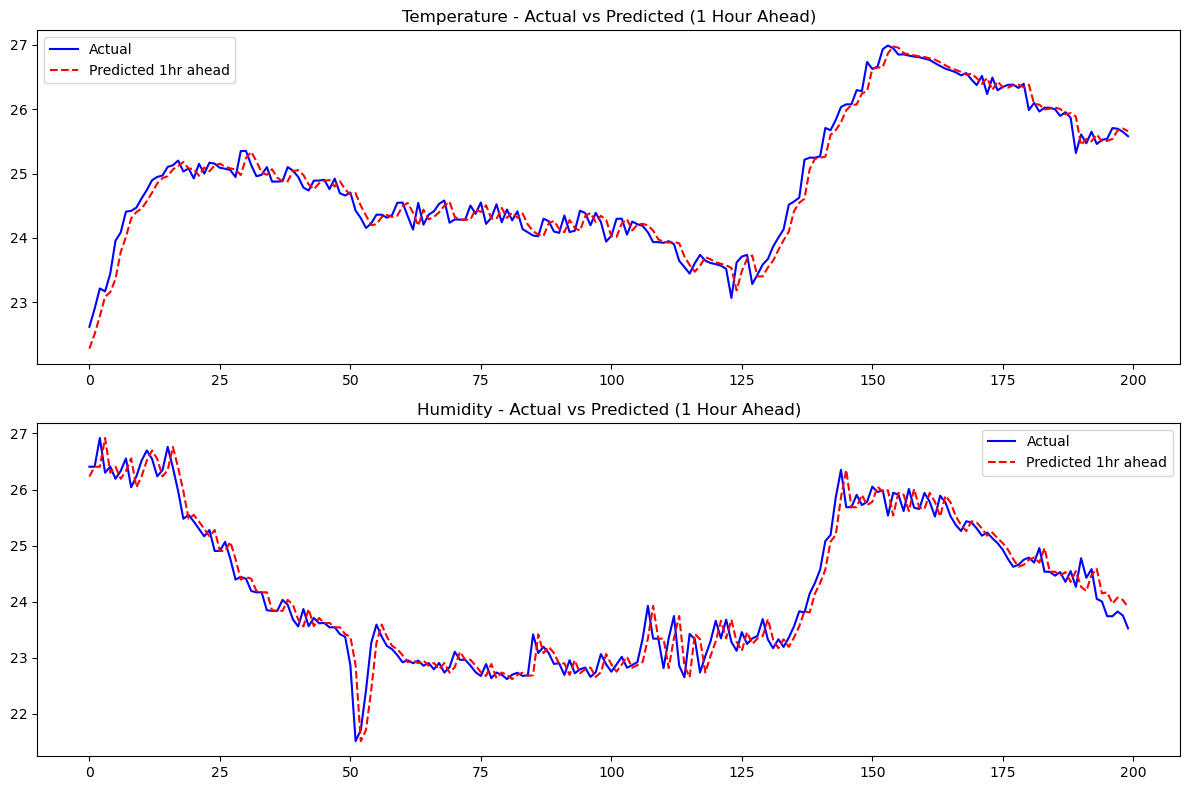

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Temperature Graph
axes[0].plot(temp_test_original, label='Actual', color='blue')
axes[0].plot(temp_predictions_original, label='Predicted',
             color='red', linestyle='--')
axes[0].set_title('Temperature - Actual vs Predicted (1 Hour Ahead)')
axes[0].legend()

# Humidity Graph
axes[1].plot(humid_test_original, label='Actual', color='blue')
axes[1].plot(humid_predictions_original, label='Predicted 1hr ahead',
             color='red', linestyle='--')
axes[1].set_title('Humidity - Actual vs Predicted (1 Hour Ahead)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Save Models

In [44]:
joblib.dump(temp_model_fit, 'arima_temperature.pk1')
joblib.dump(humid_model_fit, 'arima_humidity.pk1')

['arima_humidity.pk1']